In [1]:
%pip install ultralytics opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import os
import torch
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [3]:
print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = 0
else:
    print("Using CPU")
    device = "cpu"

PyTorch: 2.13.0+cu126
CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
model = YOLO("yolov8n.pt")

In [5]:
results = model.predict(
    source="bus.jpg",
    save=True,
    conf=0.25,
    imgsz=640,
    device=device
)


image 1/1 e:\ostad\computer_vission\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 59.3ms
Speed: 3.2ms preprocess, 59.3ms inference, 9.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to E:\ostad\runs\detect\predict-2


Save Directory: E:\ostad\runs\detect\predict-2
Image Path: E:\ostad\runs\detect\predict-2\bus.jpg


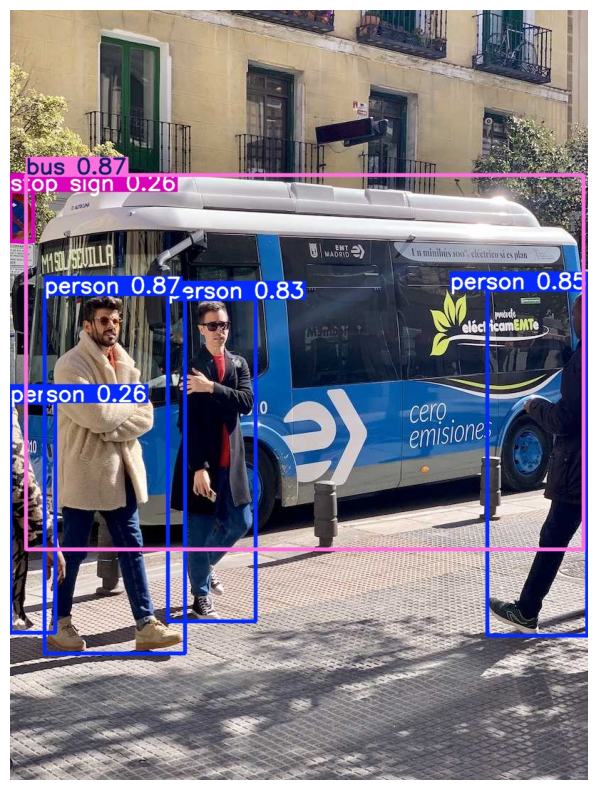

In [9]:
import os
import cv2
import matplotlib.pyplot as plt

save_dir = results[0].save_dir
print("Save Directory:", save_dir)

image_path = os.path.join(save_dir, "bus.jpg")
print("Image Path:", image_path)

img = cv2.imread(image_path)

if img is None:
    print("Image not found:", image_path)
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [10]:
video_path = "istockphoto-1186020467-640_adpp_is.mp4"

cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    "output/output_video.mp4",
    fourcc,
    fps,
    (width,height)
)

In [11]:
while True:
    
    ret, frame = cap.read()

    if not ret:
        break

    results = model.predict(
        frame,
        conf=0.25,
        verbose=False,
        device=device
    )

    annotated = results[0].plot()

    out.write(annotated)

cap.release()
out.release()

print("Done")

Done


In [13]:
import cv2

video_path = "istockphoto-1186020467-640_adpp_is.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video.")
else:
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out = cv2.VideoWriter(
        "cow_count.mp4",
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        results = model.predict(
            frame,
            conf=0.25,
            verbose=False,
            device=device
        )

        cows = 0

        for box in results[0].boxes:
            cls = int(box.cls[0])

            if model.names[cls] == "cow":
                cows += 1

        annotated = results[0].plot()

        cv2.putText(
            annotated,
            f"Cows: {cows}",
            (30, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2,
        )

        out.write(annotated)

    cap.release()
    out.release()

    print("Finished!")
    print("Saved as: cow_count.mp4")

Finished!
Saved as: cow_count.mp4


In [14]:
from IPython.display import Video

Video("output/cow_count.mp4", embed=True)

In [15]:
import os

print(os.getcwd())
print(os.path.exists("cow_count.mp4"))
print(os.path.getsize("cow_count.mp4") if os.path.exists("cow_count.mp4") else "File not found")

e:\ostad\computer_vission
True
26742767
